In [32]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
import numpy as np
import matplotlib.pyplot as plt

In [33]:
np.random.seed(42)

def make_dataset(n , noise_sd = 1.7):
    X = np.random.uniform(-3 , 3 , n).reshape(-1 , 1)
    true_w , true_b = 2.5 , -1.0
    y = true_w * X.flatten() + true_b + np.random.normal(0 , noise_sd , n)
    Xd = np.hstack([X , np.ones((n , 1))])
    return X , y , Xd

def mse(Xd , y , w):
    r = Xd @ w - y
    return float(np.mean(r * r))

def grad_full(Xd , y , w):
    n = Xd.shape[0]
    return (2.0 / n) * (Xd.T @ (Xd @ w - y))

def estimate_L(Xd):
    n = Xd.shape[0]
    H = (2.0 / n) * (Xd.T @ Xd)
    return float(np.max(np.linalg.eigvals(H).real))

def moving_average(x , window = 10):
    x = np.asarray(x , dtype = float)
    if len(x) < window:
        return x
    kernel = np.ones(window) / window
    return np.convolve(x , kernel , mode = "valid")

def first_pass_reaching(losses , passes , target):
    for L , p in zip(losses , passes):
        if L <= target:
            return p
    return None

In [34]:
def fixed_step_gd(Xd , y , epochs = 150 , alpha = None , eval_idx = None):
    n = Xd.shape[0]
    w = np.zeros(Xd.shape[1])

    losses_eval = []
    passes = []

    if eval_idx is None:
        eval_idx = np.arange(min(1000 , n))
    X_eval , y_eval = Xd[eval_idx] , y[eval_idx]

    for t in range(epochs):
        g = grad_full(Xd , y , w)
        w = w - alpha * g
        losses_eval.append(mse(X_eval , y_eval , w))
        passes.append(t + 1)

    final_full = mse(Xd , y , w)
    return {"w": w , "losses": losses_eval , "passes": passes , "final_full": final_full , "passes_compute": epochs}

In [35]:
def line_search_gd(Xd , y , epochs = 150 , alpha0 = None , beta = 0.5 , c = 1e-4 , eval_idx = None):
    n = Xd.shape[0]
    w = np.zeros(Xd.shape[1])

    losses_eval = []
    passes = []

    if eval_idx is None:
        eval_idx = np.arange(min(1000 , n))
    X_eval , y_eval = Xd[eval_idx] , y[eval_idx]

    passes_compute = 0.0

    for t in range(epochs):
        g = grad_full(Xd , y , w)
        current_loss = mse(Xd , y , w)
        gnorm2 = float(np.dot(g , g))
        passes_compute += 1.0
        a = alpha0
        k = 0

        while True:
            w_try = w - a * g
            new_loss = mse(Xd , y , w_try)
            passes_compute += 1.0
            k += 1

            if new_loss <= current_loss - c * a * gnorm2:
                w = w_try
                break

            a *= beta
            if a < 1e-14:
                w = w_try
                break

        losses_eval.append(mse(X_eval , y_eval , w))
        passes.append(passes_compute)

    final_full = mse(Xd , y , w)
    return {"w": w , "losses": losses_eval , "passes": passes , "final_full": final_full , "passes_compute": passes_compute}

In [36]:
def sgd_minibatch(Xd , y , steps = 20000 , batch_size = 256 , lr0 = 0.2 , decay = 0.5 , eval_every_pass = 0.1 , eval_idx = None):
    n = Xd.shape[0]
    d = Xd.shape[1]
    w = np.zeros(d)

    if eval_idx is None:
        eval_idx = np.arange(min(1000 , n))
    X_eval , y_eval = Xd[eval_idx] , y[eval_idx]

    losses_eval = []
    passes = []

    samples_seen = 0
    next_eval_pass = 0.0

    for t in range(1 , steps + 1):
        idx = np.random.randint(0 , n , size = batch_size)
        Xb , yb = Xd[idx] , y[idx]
        r = Xb @ w - yb
        g = (2.0 / batch_size) * (Xb.T @ r)
        lr = lr0 / (1.0 + decay * np.sqrt(t / 1000.0))
        w = w - lr * g
        samples_seen += batch_size
        cur_pass = samples_seen / n

        if cur_pass >= next_eval_pass:
            losses_eval.append(mse(X_eval , y_eval , w))
            passes.append(cur_pass)
            next_eval_pass += eval_every_pass if cur_pass < 5 else 0.5

        if cur_pass >= 35:
            break

    final_full = mse(Xd , y , w)
    return {"w": w , "losses": losses_eval , "passes": passes , "final_full": final_full , "passes_compute": (samples_seen / n)}

In [37]:
def run_suite(n , noise_sd , label):
    X , y , Xd = make_dataset(n , noise_sd = noise_sd)
    L = estimate_L(Xd)
    fixed = fixed_step_gd(Xd , y , epochs = 100 , alpha = 1.0 / L)
    line = line_search_gd(Xd , y , epochs = 60 , alpha0 = 12.0 / L , beta = 0.5 , c = 1e-4)

    if n >= 20000:
        sgd = sgd_minibatch(Xd , y , steps = 50000 , batch_size = 512 , lr0 = 0.6 / L , decay = 0.35 , eval_every_pass = 0.05)
    else:
        sgd = sgd_minibatch(Xd , y , steps = 12000 , batch_size = 64 , lr0 = 0.4 / L , decay = 0.45 , eval_every_pass = 0.05)

    return {"X": X , "y": y , "Xd": Xd , "L": L , "fixed": fixed , "line": line , "sgd": sgd , "label": label}

small = run_suite(n = 300 , noise_sd = 1.6 , label = "SMALL (n = 300)")
large = run_suite(n = 20000 , noise_sd = 1.6 , label = "LARGE (n = 20000)")

def build_summary(exp):
    fixed , line , sgd = exp["fixed"] , exp["line"] , exp["sgd"]

    best_final = min(fixed["final_full"] , line["final_full"] , sgd["final_full"])
    target_5 = best_final * 1.05
    target_1 = best_final * 1.01

    rows = []
    for name , r in [
        ("Fixed Step (1/L)" , fixed) ,
        ("Line Search" , line) ,
        ("SGD (mini-batch)" , sgd) ,
    ]:
        p5 = first_pass_reaching(r["losses"] , r["passes"] , target_5)
        p1 = first_pass_reaching(r["losses"] , r["passes"] , target_1)
        rows.append((name , r["final_full"] , p5 , p1 , r["passes_compute"]))

    return best_final , target_5 , target_1 , rows

def print_table(title, rows):
    print(title)
    print(f"{'Method':18s} {'Final Loss':>10s} {'5% to best':>12s} {'1% to best':>12s} {'Compute (passes)':>16s}")
    print("-" * 74)
    for name , final_loss , p5 , p1 , comp in rows:
        p5s = f"{p5:.2f}" if p5 is not None else "-"
        p1s = f"{p1:.2f}" if p1 is not None else "-"
        print(f"{name:18s} {final_loss:10.4f} {p5s:>12s} {p1s:>12s} {comp:16.2f}")
    print()

best_small , t5_small , t1_small , rows_small = build_summary(small)
best_large , t5_large , t1_large , rows_large = build_summary(large)

<Figure size 1200x400 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Small Dataset: Stable vs Noisy Optimization (log-loss)')

Text(0.5, 0, 'Compute proxy (data passes)')

Text(0, 0.5, 'MSE Loss')

<Axes: >

Text(0.5, 1.0, 'Small Dataset (Zoom): Fixed ≈ Line Search (same solution)')

Text(0.5, 0, 'Compute proxy (data passes)')

Text(0, 0.5, 'MSE Loss (zoomed)')

(2.4740230988196394, 2.536184483212093)

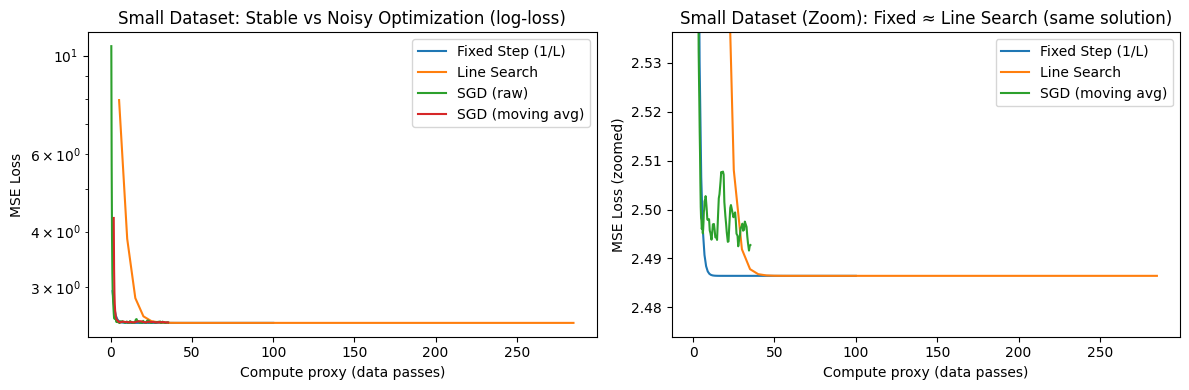

In [38]:
plt.figure(figsize = (12 , 4))
plt.subplot(1 , 2 , 1)
plt.title("Small Dataset: Stable vs Noisy Optimization (log-loss)")
plt.plot(small["fixed"]["passes"] , small["fixed"]["losses"] , label = "Fixed Step (1/L)")
plt.plot(small["line"]["passes"] , small["line"]["losses"] , label = "Line Search")
plt.plot(small["sgd"]["passes"] , small["sgd"]["losses"] , label = "SGD (raw)")
sgd_ma = moving_average(small["sgd"]["losses"] , window = 8)
sgd_ma_x = small["sgd"]["passes"][len(small["sgd"]["passes"]) - len(sgd_ma):]
plt.plot(sgd_ma_x , sgd_ma , label = "SGD (moving avg)")
plt.yscale("log")
plt.xlabel("Compute proxy (data passes)")
plt.ylabel("MSE Loss")
plt.legend()

plt.subplot(1 , 2 , 2)
plt.title("Small Dataset (Zoom): Fixed ≈ Line Search (same solution)")
plt.plot(small["fixed"]["passes"] , small["fixed"]["losses"] , label = "Fixed Step (1/L)")
plt.plot(small["line"]["passes"] , small["line"]["losses"] , label = "Line Search")
plt.plot(sgd_ma_x , sgd_ma , label = "SGD (moving avg)")
plt.xlabel("Compute proxy (data passes)")
plt.ylabel("MSE Loss (zoomed)")
y0 = best_small
plt.ylim(y0 * 0.995 , y0 * 1.02)
plt.legend()
plt.tight_layout()
plt.show()

<Figure size 1200x400 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Large Dataset: Loss vs Compute (log-loss)')

Text(0.5, 0, 'Compute proxy (data passes)')

Text(0, 0.5, 'MSE Loss')

...

Text(0.5, 1.0, 'Large Dataset (Early Zoom): 0–25 Data Passes')

(0.0, 25.0)

(2.032383892169346, 4.3459781341986)

Text(0.5, 0, 'Compute proxy (data passes)')

Text(0, 0.5, 'MSE Loss (zoomed)')

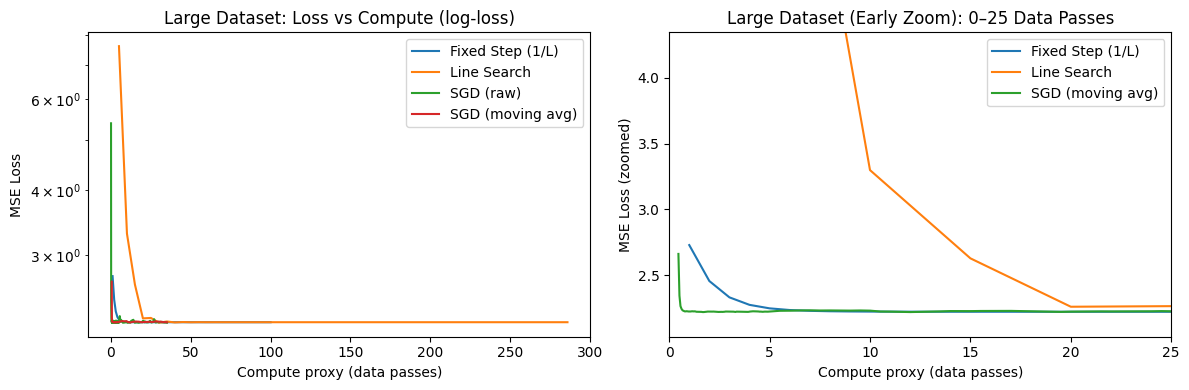

In [39]:
plt.figure(figsize = (12 , 4))
plt.subplot(1 , 2 , 1)
plt.title("Large Dataset: Loss vs Compute (log-loss)")
plt.plot(large["fixed"]["passes"] , large["fixed"]["losses"] , label = "Fixed Step (1/L)")
plt.plot(large["line"]["passes"] , large["line"]["losses"] , label = "Line Search")
plt.plot(large["sgd"]["passes"] , large["sgd"]["losses"] , label = "SGD (raw)")
sgd_maL = moving_average(large["sgd"]["losses"] , window = 10)
sgd_maL_x = large["sgd"]["passes"][len(large["sgd"]["passes"]) - len(sgd_maL) : ]
plt.plot(sgd_maL_x , sgd_maL , label = "SGD (moving avg)")
plt.yscale("log")
plt.xlabel("Compute proxy (data passes)")
plt.ylabel("MSE Loss")
plt.legend()

plt.subplot(1 , 2 , 2)
plt.title("Large Dataset (Early Zoom): 0–25 Data Passes")
plt.plot(large["fixed"]["passes"] , large["fixed"]["losses"] , label = "Fixed Step (1/L)")
plt.plot(large["line"]["passes"] , large["line"]["losses"] , label = "Line Search")
plt.plot(sgd_maL_x , sgd_maL , label = "SGD (moving avg)")
plt.xlim(0 , 25)
y_min = best_large
plt.ylim(y_min * 0.795 , y_min * 1.7)
plt.xlabel("Compute proxy (data passes)")
plt.ylabel("MSE Loss (zoomed)")
plt.legend()
plt.tight_layout()
plt.show()

<Figure size 1000x400 with 0 Axes>

Text(0.5, 1.0, 'Large Dataset (Near-Optimum Zoom): Stability vs Noise Floor')

Text(0.5, 0, 'Compute proxy (data passes)')

Text(0, 0.5, 'MSE Loss (tight zoom)')

(0.0, 25.0)

(2.032383892169346, 3.32339504379893)

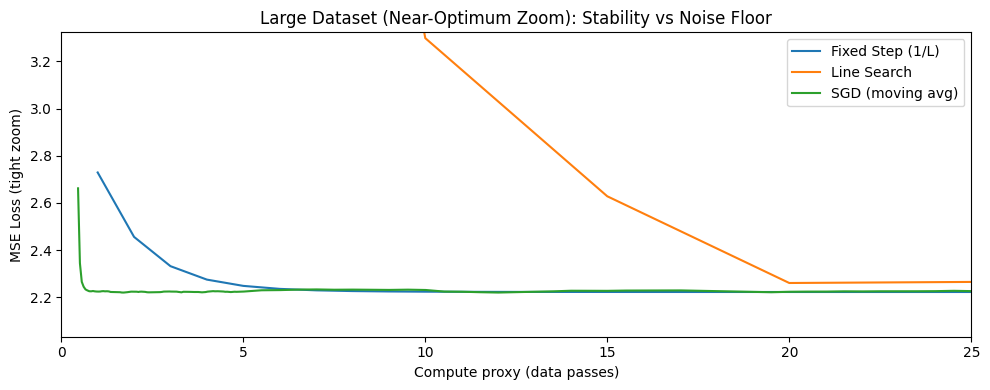

In [40]:
plt.figure(figsize = (10 , 4))
plt.title("Large Dataset (Near-Optimum Zoom): Stability vs Noise Floor")
plt.plot(large["fixed"]["passes"] , large["fixed"]["losses"] , label = "Fixed Step (1/L)")
plt.plot(large["line"]["passes"] , large["line"]["losses"] , label = "Line Search")
plt.plot(sgd_maL_x , sgd_maL , label = "SGD (moving avg)")
plt.xlabel("Compute proxy (data passes)")
plt.ylabel("MSE Loss (tight zoom)")
plt.xlim(0 , 25)
plt.ylim(best_large * 0.795 , best_large * 1.30)
plt.legend()
plt.tight_layout()
plt.show()

In [41]:
print_table("SMALL DATASET SUMMARY (n = 300)" , rows_small)
print_table("LARGE DATASET SUMMARY (n = 20000)" , rows_large)

SMALL DATASET SUMMARY (n = 300)
Method             Final Loss   5% to best   1% to best Compute (passes)
--------------------------------------------------------------------------
Fixed Step (1/L)       2.4865         3.00         5.00           100.00
Line Search            2.4865        20.00        25.00           285.00
SGD (mini-batch)       2.4911         1.92         3.20            35.20

LARGE DATASET SUMMARY (n = 20000)
Method             Final Loss   5% to best   1% to best Compute (passes)
--------------------------------------------------------------------------
Fixed Step (1/L)       2.5565         2.00         2.00           100.00
Line Search            2.5565        15.00        20.00           286.00
SGD (mini-batch)       2.5587         0.10         0.10            35.02

